# IEA - SISEPUEDE Energy Crosswalk — Comparison Notebook

This notebook is a **walkthrough** of `sisepuede/calibration/iea_crosswalk.py`.
All the real logic lives in that module; here we just call it step-by-step
so you can see what each piece does.

**Steps:**
1. Setup — imports, paths
2. Run SISEPUEDE energy model
3. Build an `IEACrosswalk` object (loads the mapping CSV)
4. Aggregate SISEPUEDE outputs using the crosswalk
5. Load and normalise IEA data
6. Build the comparison table
7. Summarise and visualise

---
## 1. Setup

We import the SISEPUEDE file structure (gives us model attributes and
the path to the ref directory) and our new `IEACrosswalk` class.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
# Add the sisepuede repo root so local edits take precedence over the installed package
path = "/Users/dianamendez/feature-energy-calibration"
if path not in sys.path:
    sys.path.insert(0, path)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
from sisepuede.calibration.iea_crosswalk        import IEACrosswalk
from sisepuede.calibration.iea_data_loader      import IEADataLoader

# ── Paths — change these ─────────────────────────────────────────────────────
PATH_SISEPUEDE_INPUT = "/Users/dianamendez/sisepuede-data/input_data_peru_base.csv"
PATH_IEA_DATA_DIR    = "/Users/dianamendez/data_collection_temporary"
PATH_CROSSWALK_FILE  = "/Users/dianamendez/feature-energy-calibration/sisepuede/ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv"
PATH_OUTPUT_DIR      = "/Users/dianamendez/sisepuede-data"

ISO_COUNTRY          = "PER"
START_YEAR           = 2015   # first year of the comparison window
TRUE_DATA_LIMIT_YEAR = 2022   # last year of actual IEA data (rows beyond are projections)
YEAR_TARGET          = 2018   # reference year to calibrate to
# ─────────────────────────────────────────────────────────────────────────────
# Run this notebook with the sisepuede-env kernel:
#   /Users/dianamendez/sisepuede-env/bin/python

file_struct      = SISEPUEDEFileStructure()
model_attributes = file_struct.model_attributes

---
## 2. Run SISEPUEDE — get energy outputs

`EnergyConsumption` depends on `AFOLU` and `IPPU`, so we run those first and merge their outputs in before calling the energy model.

In [2]:
from sisepuede.models.afolu              import AFOLU
from sisepuede.models.energy_consumption import EnergyConsumption
from sisepuede.models.ippu               import IPPU

model_afolu     = AFOLU            (model_attributes)
model_ippu      = IPPU             (model_attributes)
model_energycon = EnergyConsumption(model_attributes)

df_input = pd.read_csv(PATH_SISEPUEDE_INPUT)
df_input['year'] = range(2015,2015+len(df_input))
col = df_input.pop('year')
df_input.insert(0, 'year', col)

# Only use truth available data for comparison
true_data_condition = df_input["year"] <= TRUE_DATA_LIMIT_YEAR
df_input = df_input.loc[true_data_condition]
print(f"Input shape: {df_input.shape}")
display(df_input)

# Run dependency models first, then merge their outputs as additional inputs
df_out_afolu = model_afolu(df_input)
df_out_ippu  = model_ippu (df_input)

df_input_energy = df_input.merge(df_out_afolu, how="left").merge(df_out_ippu, how="left")
df_out_energycon = model_energycon(df_input_energy)

print(f"Output shape: {df_out_energycon.shape}")
display(df_out_energycon)

Input shape: (8, 2420)


,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,nemomod_entc_scalar_availability_factor_pp_gas_ccs,nemomod_entc_scalar_availability_factor_pp_geothermal,nemomod_entc_scalar_availability_factor_pp_hydropower,nemomod_entc_scalar_availability_factor_pp_nuclear,nemomod_entc_scalar_availability_factor_pp_ocean,nemomod_entc_scalar_availability_factor_pp_oil,nemomod_entc_scalar_availability_factor_pp_solar,nemomod_entc_scalar_availability_factor_pp_waste_incineration,nemomod_entc_scalar_availability_factor_pp_wind,region
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,peru
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,peru
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,peru
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,peru
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,peru
5,2020,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,peru
6,2021,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,peru
7,2022,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,peru


Output shape: (8, 549)


,time_period,dem_trde_freight_mt_km,dem_trde_private_and_public_passenger_km,dem_trde_regional_passenger_km,emission_co2e_ch4_ccsq_direct_air_capture,emission_co2e_ch4_inen_agriculture_and_livestock,emission_co2e_ch4_inen_cement,emission_co2e_ch4_inen_chemicals,emission_co2e_ch4_inen_electronics,emission_co2e_ch4_inen_glass,...,vehicle_distance_traveled_trns_road_light_diesel,vehicle_distance_traveled_trns_road_light_electricity,vehicle_distance_traveled_trns_road_light_gasoline,vehicle_distance_traveled_trns_road_light_hydrocarbon_gas_liquids,vehicle_distance_traveled_trns_road_light_hydrogen,vehicle_distance_traveled_trns_water_borne,vehicle_distance_traveled_trns_water_borne_diesel,vehicle_distance_traveled_trns_water_borne_electricity,vehicle_distance_traveled_trns_water_borne_hydrogen,vehicle_distance_traveled_trns_water_borne_natural_gas
0,0,412987.581617,1.138393e+11,9.971930e+09,0.0,0.018308,0.006806,0.002348,0.000438,0.001134,...,1.334453e+10,3.463070e+08,1.799744e+10,0.0,0.0,1.077531e+07,1.077531e+07,0.0,0.0,0.0
1,1,429316.377086,1.186763e+11,1.076845e+10,0.0,0.018388,0.014708,0.000520,0.000250,0.002030,...,1.390719e+10,3.602037e+08,1.883413e+10,0.0,0.0,1.128922e+07,1.128922e+07,0.0,0.0,0.0
2,2,440127.628917,1.217848e+11,1.118840e+10,0.0,0.018474,0.020011,0.000149,0.000000,0.000000,...,1.425518e+10,3.684858e+08,1.937041e+10,0.0,0.0,1.158763e+07,1.158763e+07,0.0,0.0,0.0
3,3,457597.985138,1.269457e+11,1.204284e+10,0.0,0.018787,0.021623,0.000325,0.000000,0.000000,...,1.486055e+10,3.834608e+08,2.025722e+10,0.0,0.0,1.214874e+07,1.214874e+07,0.0,0.0,0.0
4,4,467849.648366,1.298828e+11,1.243332e+10,0.0,0.018969,0.019773,0.000332,0.000000,0.000000,...,1.518214e+10,3.911972e+08,2.076987e+10,0.0,0.0,1.250281e+07,1.250281e+07,0.0,0.0,0.0
5,5,416994.236023,1.138491e+11,8.575963e+09,0.0,0.019190,0.000000,0.000994,0.000158,0.000000,...,1.310908e+10,3.374290e+08,1.801308e+10,0.0,0.0,1.100831e+07,1.100831e+07,0.0,0.0,0.0
6,6,472941.904663,1.315185e+11,1.219156e+10,0.0,0.019230,0.000000,0.000927,0.000148,0.000000,...,1.502936e+10,3.850801e+08,2.136928e+10,0.0,0.0,1.208613e+07,1.208613e+07,0.0,0.0,0.0
7,7,485644.565977,1.353860e+11,1.294347e+10,0.0,0.019422,0.000000,0.000909,0.000145,0.000000,...,1.536975e+10,3.909275e+08,2.219736e+10,0.0,0.0,1.241401e+07,1.241401e+07,0.0,0.0,0.0


Select specific SISEPUEDE output variables to look at

In [3]:
list(df_input_energy.filter(like="frac_inen_energy_cement"))

['frac_inen_energy_cement_coal',
 'frac_inen_energy_cement_coke',
 'frac_inen_energy_cement_diesel',
 'frac_inen_energy_cement_electricity',
 'frac_inen_energy_cement_furnace_gas',
 'frac_inen_energy_cement_gasoline',
 'frac_inen_energy_cement_hydrocarbon_gas_liquids',
 'frac_inen_energy_cement_hydrogen',
 'frac_inen_energy_cement_kerosene',
 'frac_inen_energy_cement_natural_gas',
 'frac_inen_energy_cement_oil',
 'frac_inen_energy_cement_solar',
 'frac_inen_energy_cement_solid_biomass']

In [4]:
# SISEPUEDE outputs use integer time_period (0, 1, 2 ...) but IEA uses
# calendar years.  We build a time_period -> year map from the input file
# and add the year column to the output.

df_tp_year = (
    df_input[["year"]]
    .reset_index(drop=True)
    .reset_index()           # creates 'index' column = time_period
    .rename(columns={"index": "time_period"})
)

df_out_energycon = df_out_energycon.merge(df_tp_year, on="time_period", how="left")
df_out_energycon[["time_period", "year"]].head()

print(f"Output dataframe shape: {df_out_energycon.shape}")

Output dataframe shape: (8, 550)


In [5]:
# select_variables = ["energy_demand_enfu_subsector_total_pj_scoe_fuel_biofuels", "energy_demand_enfu_subsector_total_pj_scoe_fuel_biogas","energy_demand_enfu_subsector_total_pj_scoe_fuel_biomass"]
# display(df_out_energycon[select_variables])

display(df_out_energycon.filter(like="energy_demand"))

,energy_demand_enfu_subsector_total_pj_ccsq_fuel_biofuels,energy_demand_enfu_subsector_total_pj_ccsq_fuel_biogas,energy_demand_enfu_subsector_total_pj_ccsq_fuel_biomass,energy_demand_enfu_subsector_total_pj_ccsq_fuel_coal,energy_demand_enfu_subsector_total_pj_ccsq_fuel_coke,energy_demand_enfu_subsector_total_pj_ccsq_fuel_crude,energy_demand_enfu_subsector_total_pj_ccsq_fuel_diesel,energy_demand_enfu_subsector_total_pj_ccsq_fuel_electricity,energy_demand_enfu_subsector_total_pj_ccsq_fuel_furnace_gas,energy_demand_enfu_subsector_total_pj_ccsq_fuel_gasoline,...,energy_demand_inen_recycled_plastic,energy_demand_inen_recycled_rubber_and_leather,energy_demand_inen_recycled_textiles,energy_demand_inen_recycled_wood,energy_demand_inen_rubber_and_leather,energy_demand_inen_textiles,energy_demand_inen_wood,energy_demand_scoe_heat_commercial_municipal,energy_demand_scoe_heat_other_se,energy_demand_scoe_heat_residential
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,5.714682,3.545212,63.856486,254.957131,0.0,193.672982
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,7.355548,5.490663,65.118872,264.274459,0.0,201.629807
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.385292,0.000000,65.938799,256.446618,0.0,203.150715
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,7.336769,0.000000,67.247481,204.260638,0.0,194.846120
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,8.357549,0.000000,68.000761,204.738508,0.0,197.938976
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,23.082489,2.505264,64.304908,-106.521728,0.0,216.519670
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,26.434014,2.846871,68.618769,-109.772987,0.0,207.688158
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,27.091397,2.912817,69.261558,-111.650548,0.0,209.026656


In [6]:
df_out = df_out_energycon[[x for x in df_out_energycon.columns if "energy_consumption_inen" in x and "total" not in x]].copy()
df_out.sum(axis=1)

df_totals = df_out_energycon[["energy_consumption_inen_total"]].copy()
df_totals                           

# check that the sum of all the disaggregated scoe demands equal the total scoe demand variable
df_out = df_out_energycon[[x for x in df_out_energycon.columns if "energy_demand_enfu_subsector_total_pj_scoe_commercial_and_public" in x or "energy_demand_enfu_subsector_total_pj_scoe_residential" in x or "energy_demand_enfu_subsector_total_pj_scoe_other" in x]].copy()
display(df_out.sum(axis=1))

df_total_scoe = df_out_energycon[[x for x in df_out_energycon.columns if "energy_demand_enfu_subsector_total_pj_scoe" in x and "commercial" not in x and "residential" not in x and "other" not in x and "other" not in x]].copy()
df_total_scoe.sum(axis=1)

0    950.453659
1    987.929969
2    990.167454
3    929.617136
4    943.441280
5    637.848106
6    649.771959
7    658.813405
dtype: float64

0    950.453659
1    987.929969
2    990.167454
3    929.617136
4    943.441280
5    637.848106
6    649.771959
7    658.813405
dtype: float64

---
## 3. Build the `IEACrosswalk` object

`IEACrosswalk.__init__()` does two things:
- Stores a reference to `SISEPUEDERegions`, which holds IEA field name constants (`Balance`, `Country`, `Product`, `Time`, `Unit`, `Value`) and the country-name cleaning utilities.
- Reads and cleans `ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv`, dropping blank separator rows and `no_match` entries.

In [7]:
from sisepuede.calibration.build_iea_energy_crosswalk import IEACrosswalkBuilder

# #Do this if creating or updating the crosswalk
builder = IEACrosswalkBuilder(model_attributes, PATH_CROSSWALK_FILE)
df_xw = builder.build(write_csv=True)

xw = IEACrosswalk(model_attributes, path_crosswalk = PATH_CROSSWALK_FILE)

print(f"Crosswalk loaded: {len(xw.df_crosswalk)} mappable entries")
print("IEA field names:",
      xw.field_balance, xw.field_country,
      xw.field_product, xw.field_time,
      xw.field_unit, xw.field_value)

# Preview the crosswalk table
xw.df_crosswalk[["iea_balance_code", "iea_product_code",
                  "sisepuede_subsector", "aggregation",
                  "unit_conversion_to_tj", "mapping_quality"]].head(10)

IEA crosswalk written to: /Users/dianamendez/feature-energy-calibration/sisepuede/ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv
Crosswalk loaded: 51 mappable entries
IEA field names: Balance Country Product Time Unit Value


,iea_balance_code,iea_product_code,sisepuede_subsector,aggregation,unit_conversion_to_tj,mapping_quality
0,COALIMPORTS,IMPORTS,enfu,sum,1000.0,exact
1,COALEXPORTS,EXPORTS,enfu,sum,1000.0,exact
2,CRUDIMPORTS,IMPORTS,enfu,direct,1000.0,exact
3,CRUDEXPORTS,EXPORTS,enfu,direct,1000.0,exact
4,GASIMPORTS,IMPORTS,enfu,direct,1000.0,exact
5,GASEXPORTS,EXPORTS,enfu,direct,1000.0,exact
6,ELIMPORTS,IMPORTS,enfu,direct,1000.0,exact
7,ELEXPORTS,EXPORTS,enfu,direct,1000.0,exact
8,ELECTOUT,COAL,entc,sum,1000.0,exact
9,ELECTOUT,OIL,entc,direct,1000.0,approximate


---
## 4. Aggregate SISEPUEDE outputs -> `df_sisepuede_long`

`xw.aggregate_sisepuede()` iterates through every crosswalk row and:

1. Splits the `sisepuede_output_variables` cell on `:` to get the list of SISEPUEDE column names.
   - *Example:* `nemomod_entc_annual_production_by_technology_pp_coal:nemomod_entc_annual_production_by_technology_pp_coal_ccs`

2. Intersects that list with columns that actually exist in `df_out_energycon`.
   Technologies not deployed in a given country will be absent — that is fine.

3. Sums the surviving columns for each year.  
   (Summing a single column is a no-op, so `direct` and `sum` both go through
   the same code path.)

4. Multiplies by `unit_conversion_to_tj` (1000 for PJ→TJ energy variables;
   1 for GW capacity variables).

Result is long-format: one row per (crosswalk entry × year).

In [8]:
df_sisepuede_long = xw.aggregate_sisepuede(df_out_energycon, col_year="year")

print(f"Shape: {df_sisepuede_long.shape}")
df_sisepuede_long.head(15)

Shape: (232, 10)


,year,value_sisepuede_tj,iea_balance_code,iea_balance_name,iea_product_code,iea_product_name,sisepuede_subsector,unit_sisepuede,mapping_quality,sisepuede_vars_used
0,2015,6.193190e+05,INDUSTRY,Total final energy consumption,INDUSTRY,Industry,inen,PJ,approximate,energy_consumption_inen_cement:energy_consumpt...
1,2016,8.275485e+05,INDUSTRY,Total final energy consumption,INDUSTRY,Industry,inen,PJ,approximate,energy_consumption_inen_cement:energy_consumpt...
2,2017,4.687994e+05,INDUSTRY,Total final energy consumption,INDUSTRY,Industry,inen,PJ,approximate,energy_consumption_inen_cement:energy_consumpt...
3,2018,5.706292e+05,INDUSTRY,Total final energy consumption,INDUSTRY,Industry,inen,PJ,approximate,energy_consumption_inen_cement:energy_consumpt...
4,2019,5.683085e+05,INDUSTRY,Total final energy consumption,INDUSTRY,Industry,inen,PJ,approximate,energy_consumption_inen_cement:energy_consumpt...
5,2020,1.096379e+06,INDUSTRY,Total final energy consumption,INDUSTRY,Industry,inen,PJ,approximate,energy_consumption_inen_cement:energy_consumpt...
6,2021,1.246748e+06,INDUSTRY,Total final energy consumption,INDUSTRY,Industry,inen,PJ,approximate,energy_consumption_inen_cement:energy_consumpt...
7,2022,1.273409e+06,INDUSTRY,Total final energy consumption,INDUSTRY,Industry,inen,PJ,approximate,energy_consumption_inen_cement:energy_consumpt...
8,2015,3.220053e+05,TRANSPORT,Total final energy consumption,TRANSPORT,Transport,trns,PJ,exact,energy_consumption_trns_total
9,2016,3.321989e+05,TRANSPORT,Total final energy consumption,TRANSPORT,Transport,trns,PJ,exact,energy_consumption_trns_total


In [9]:
# How many distinct (balance, product) pairs did we produce?
(
    df_sisepuede_long
    .groupby(["iea_balance_code", "iea_product_code", "mapping_quality"])
    .size()
    .reset_index(name="n_years")
)

,iea_balance_code,iea_product_code,mapping_quality,n_years
0,AGRICULT,AGRICULT,partial,8
1,COMMPUB,BIOWASTE,approximate,8
2,COMMPUB,COAL,approximate,8
3,COMMPUB,COMMPUB,exact,8
4,COMMPUB,ELECTR,approximate,8
5,COMMPUB,GEOTHERM,approximate,8
6,COMMPUB,NATGAS,approximate,8
7,COMMPUB,OIL,approximate,8
8,INDUSTRY,BIOWASTE,approximate,8
9,INDUSTRY,COAL,approximate,8


---
## 5. Load IEA data -> `df_iea_long`

`IEADataLoader.load_country()` scans the local IEA CSV repository (one file per country per topic) and returns a single long DataFrame with columns `(iso_alpha_3, iea_balance_code, iea_product_code, year, value_tj)`.

Under the hood it:
1. Searches each configured folder for a file whose name contains the country.
2. Detects the CSV layout (Format A: row-label leading; Format B: year-leading).
3. Maps row labels to `(iea_balance_code, iea_product_code)` using internal
   dictionaries that match the codes in the crosswalk.
4. Converts all units to TJ (GWh x 3.6, ktoe x 41.868, TJ x 1).

The result can be passed directly to `xw.build_comparison()` — no further normalisation is needed.

In [10]:
loader = IEADataLoader(PATH_IEA_DATA_DIR, model_attributes)

print("Folders that will be searched:")
for f in loader.available_folders():
    print(f"  {f}")

Folders that will be searched:
  coal_imports_and_exports
  commercial_and_public_services_total_final_consumption_by_source
  crude_oil_imports_and_exports
  electricity_generation_sources
  electricity_imports_and_exports
  energy_imports_and_exports
  industry_total_final_consumption_by_source
  natural_gas_imports_and_exports
  residential_total_final_consumption_by_source
  total_energy_supply
  total_final_energy_consumption
  transport_total_final_consumption_by_source


In [11]:
df_iea_long = loader.load_country(ISO_COUNTRY)
# df_iea_long = loader.load_country(ISO_COUNTRY, country_name="Libya")
display(df_iea_long)

print(f"IEA rows loaded: {len(df_iea_long)}")
print(f"Folders found:   {df_iea_long['source_folder'].nunique()}")
print(f"Years covered:   {df_iea_long['year'].min()} – {df_iea_long['year'].max()}")

if len(df_iea_long):
    print(f"\n(balance, product) pairs:")
    print(df_iea_long[['iea_balance_code','iea_product_code']].drop_duplicates()
          .sort_values(['iea_balance_code','iea_product_code']).to_string(index=False))

,iso_alpha_3,iea_balance_code,iea_product_code,year,value_iea_tj,source_folder
0,PER,AGRICULT,AGRICULT,2000,13680.0,total_final_energy_consumption
1,PER,AGRICULT,AGRICULT,2001,11470.0,total_final_energy_consumption
2,PER,AGRICULT,AGRICULT,2002,12192.0,total_final_energy_consumption
3,PER,AGRICULT,AGRICULT,2003,12501.0,total_final_energy_consumption
4,PER,AGRICULT,AGRICULT,2004,11772.0,total_final_energy_consumption
...,...,...,...,...,...,...
965,PER,TRANSPORT,TRANSPORT,2018,358106.0,total_final_energy_consumption
966,PER,TRANSPORT,TRANSPORT,2019,378954.0,total_final_energy_consumption
967,PER,TRANSPORT,TRANSPORT,2020,294622.0,total_final_energy_consumption
968,PER,TRANSPORT,TRANSPORT,2021,389287.0,total_final_energy_consumption


IEA rows loaded: 970
Folders found:   12
Years covered:   2000 – 2022

(balance, product) pairs:
iea_balance_code iea_product_code
        AGRICULT         AGRICULT
     COALEXPORTS          EXPORTS
     COALIMPORTS          IMPORTS
         COMMPUB         BIOWASTE
         COMMPUB             COAL
         COMMPUB          COMMPUB
         COMMPUB           ELECTR
         COMMPUB         GEOTHERM
         COMMPUB           NATGAS
         COMMPUB              OIL
        ELECTOUT          BIOFUEL
        ELECTOUT             COAL
        ELECTOUT            HYDRO
        ELECTOUT           NATGAS
        ELECTOUT              OIL
        ELECTOUT          SOLARPV
        ELECTOUT             WIND
       ELEXPORTS          EXPORTS
       ELIMPORTS          IMPORTS
         EXPORTS          EXPORTS
      GASEXPORTS          EXPORTS
         IMPORTS          IMPORTS
         INDPROD         BIOWASTE
         INDPROD             COAL
         INDPROD         GEOTHERM
         INDPROD   

### 5.2 Explore specific IEA data using `IEADataLoader`

Let's take a look at a specific folder, just because:

In [12]:
# folder = "industry_total_final_consumption_by_source"
folder = "total_final_energy_consumption"
cfg    = loader.folder_config[folder]
path   = loader._find_file_in_folder(folder, "Peru")

print(f"Data from {folder} directory")
print(f"cfg:    {cfg}")
fmt = cfg.get("format") or loader._detect_format(path)
print(f"format: {fmt}")

# Try parsing directly — bypasses the try/except
result = loader._parse_format_a(path, cfg)
print(f"\nresult shape: {result.shape}")
print(result.head(10))

# Also look at the raw file
import pandas as pd
raw = pd.read_csv(path, header=0)
print(f"\nraw columns: {raw.columns.tolist()}")
print(raw.head(10))


Data from total_final_energy_consumption directory
cfg:    {'format': 'A', 'balance_fixed': None, 'mode': 'balance_from_row'}
format: A

result shape: (115, 4)
  iea_balance_code iea_product_code  year  value_iea_tj
0        TRANSPORT        TRANSPORT  2000      134129.0
1        TRANSPORT        TRANSPORT  2001      125016.0
2        TRANSPORT        TRANSPORT  2002      123277.0
3        TRANSPORT        TRANSPORT  2003      129252.0
4        TRANSPORT        TRANSPORT  2004      145909.0
5        TRANSPORT        TRANSPORT  2005      138756.0
6        TRANSPORT        TRANSPORT  2006      149341.0
7        TRANSPORT        TRANSPORT  2007      156284.0
8        TRANSPORT        TRANSPORT  2008      191749.0
9        TRANSPORT        TRANSPORT  2009      213260.0

raw columns: ['total final consumption in Peru', 'Value', 'Year', 'Units']
  total final consumption in Peru   Value  Year Units
0                Transport Sector  134129  2000    TJ
1                Transport Sector  12501

---
## 6. Build the comparison table

`xw.build_comparison()` does an **outer join** on `(iea_balance_code, iea_product_code, year)`.

Outer join means:
- If SISEPUEDE has a value but IEA doesn't -> `value_iea_tj` is NaN.
- If IEA has a value but SISEPUEDE doesn't -> `value_sisepuede_tj` is NaN.
- Both present -> we get the ratio.

The `rel_err` column is the key calibration signal: it tells us how big the discrepancy is as a fraction of the historical IEA data (assumed true value).

In [13]:
df_comparison = xw.build_comparison(df_sisepuede_long, df_iea_long,
                                    year_min=START_YEAR, year_max=TRUE_DATA_LIMIT_YEAR)

print(f"Comparison table shape: {df_comparison.shape}")
df_comparison.head()

Comparison table shape: (401, 16)


,year,value_sisepuede_tj,iea_balance_code,iea_balance_name,iea_product_code,iea_product_name,sisepuede_subsector,unit_sisepuede,mapping_quality,sisepuede_vars_used,iso_alpha_3,value_iea_tj,source_folder,ratio,diff,rel_err
0,2015,62438.064913,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,PER,9840.0,total_final_energy_consumption,6.345332,52598.064913,5.345332
1,2016,62710.170063,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,PER,14423.0,total_final_energy_consumption,4.347928,48287.170063,3.347928
2,2017,63953.849457,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,PER,8392.0,total_final_energy_consumption,7.620811,55561.849457,6.620811
3,2018,65094.652656,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,PER,6436.0,total_final_energy_consumption,10.114147,58658.652656,9.114147
4,2019,65385.698293,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,PER,6741.0,total_final_energy_consumption,9.699703,58644.698293,8.699703


Check data coverage across pairs

In [14]:
total_pairs = df_comparison[['iea_balance_code', 'iea_product_code']].drop_duplicates()
pairs_with_iea = df_comparison[df_comparison['value_iea_tj'].notna()][['iea_balance_code', 'iea_product_code']].drop_duplicates()
pairs_with_ssp = df_comparison[df_comparison['value_sisepuede_tj'].notna()][['iea_balance_code', 'iea_product_code']].drop_duplicates()
pairs_with_both = df_comparison[df_comparison['value_iea_tj'].notna() & df_comparison['value_sisepuede_tj'].notna()][['iea_balance_code', 'iea_product_code']].drop_duplicates()

print(f"Total unique (balance, product) pairs in crosswalk: {len(total_pairs)}")
print(f"Pairs with IEA data: {len(pairs_with_iea)}")
print(f"Pairs with SISEPUEDE data: {len(pairs_with_ssp)}")
print(f"Pairs with both datasets: {len(pairs_with_both)}")

# Show pairs missing from each side
missing_iea = pairs_with_ssp[~pairs_with_ssp.set_index(['iea_balance_code', 'iea_product_code']).index.isin(pairs_with_iea.set_index(['iea_balance_code', 'iea_product_code']).index)]
missing_ssp = pairs_with_iea[~pairs_with_iea.set_index(['iea_balance_code', 'iea_product_code']).index.isin(pairs_with_ssp.set_index(['iea_balance_code', 'iea_product_code']).index)]

if len(pairs_with_both) > 0:
    print(f"\nPairs with both SISEPUEDE and IEA data ({len(pairs_with_both)}):")
    print(pairs_with_both.to_string(index=False))
if len(missing_iea) > 0:
    print(f"\nPairs with SISEPUEDE but no IEA data ({len(missing_iea)}):")
    print(missing_iea.to_string(index=False))
if len(missing_ssp) > 0:
    print(f"\nPairs with IEA but no SISEPUEDE data ({len(missing_ssp)}):")
    print(missing_ssp.to_string(index=False))

Total unique (balance, product) pairs in crosswalk: 51
Pairs with IEA data: 48
Pairs with SISEPUEDE data: 29
Pairs with both datasets: 26

Pairs with both SISEPUEDE and IEA data (26):
iea_balance_code iea_product_code
        AGRICULT         AGRICULT
         COMMPUB         BIOWASTE
         COMMPUB             COAL
         COMMPUB          COMMPUB
         COMMPUB           ELECTR
         COMMPUB         GEOTHERM
         COMMPUB           NATGAS
         COMMPUB              OIL
        INDUSTRY         BIOWASTE
        INDUSTRY             COAL
        INDUSTRY           ELECTR
        INDUSTRY         GEOTHERM
        INDUSTRY         INDUSTRY
        INDUSTRY           NATGAS
        INDUSTRY              OIL
        RESIDENT         BIOWASTE
        RESIDENT           ELECTR
        RESIDENT         GEOTHERM
        RESIDENT           NATGAS
        RESIDENT              OIL
        RESIDENT         RESIDENT
       TRANSPORT         BIOWASTE
       TRANSPORT           ELECTR


In [15]:
### Inspect a specific (balance, product) pair
# Change bal / prod to explore any pair — useful for diagnosing coverage gaps.

bal, prod = "INDUSTRY", "OIL"

fields = xw.get_ssp_fields_for_target(bal, prod)
entry  = xw.get_crosswalk_entry(bal, prod)

if entry is None:
    print(f"No crosswalk entry found for ({bal}, {prod})")
else:
    print(f"Target             : ({bal}, {prod})")
    print(f"Mapping quality    : {entry.mapping_quality}")
    print(f"Aggregation        : {entry.aggregation}")
    print(f"Unit conversion    : x{entry.unit_conversion_to_tj:.0f}  (SSP unit -> TJ)")
    print(f"SSP fields ({len(fields)}):")
    for f in fields:
        in_output = f in df_out_energycon.columns
        print(f"  {'OK' if in_output else 'MISSING':<8} {f}")

Target             : (INDUSTRY, OIL)
Mapping quality    : approximate
Aggregation        : sum
Unit conversion    : x1000  (SSP unit -> TJ)
SSP fields (7):
  OK       energy_demand_enfu_subsector_total_pj_inen_fuel_biofuels
  OK       energy_demand_enfu_subsector_total_pj_inen_fuel_crude
  OK       energy_demand_enfu_subsector_total_pj_inen_fuel_diesel
  OK       energy_demand_enfu_subsector_total_pj_inen_fuel_gasoline
  OK       energy_demand_enfu_subsector_total_pj_inen_fuel_hydrocarbon_gas_liquids
  OK       energy_demand_enfu_subsector_total_pj_inen_fuel_kerosene
  OK       energy_demand_enfu_subsector_total_pj_inen_fuel_oil


---
## 7. Summary table

`xw.summary()` collapses the comparison to one row per (balance, product), showing the mean ratio and the mean absolute values for both sides.

This is **one** of the diagnostic tool we'll use to prioritise which variables to tune.

In [16]:
df_summary = xw.summary(df_comparison)
df_summary

,iea_balance_code,iea_product_code,iea_balance_name,iea_product_name,mapping_quality,n_years_matched,mean_ratio,mean_rel_err,mean_iea_tj,mean_sisepuede_tj
0,COMMPUB,NATGAS,Commercial and public services total final con...,Natural gas,approximate,8,44.071224,43.071224,5909.500,63429.227959
1,RESIDENT,NATGAS,Residential total final consumption by source,Natural gas,approximate,8,20.566715,19.566715,6053.875,100947.036614
2,INDUSTRY,BIOWASTE,Industry total final consumption by source,Biofuels and waste,approximate,8,11.048687,10.048687,17151.375,183495.424359
3,COMMPUB,ELECTR,Commercial and public services total final con...,Electricity,approximate,8,9.084426,8.084426,31388.000,285196.424471
4,AGRICULT,AGRICULT,Total final energy consumption,Agriculture / forestry,partial,8,8.111729,7.111729,8505.250,64688.909674
5,COMMPUB,COMMPUB,Total final energy consumption,Commercial and public services,exact,8,7.358140,6.358140,53939.750,388718.272154
6,INDUSTRY,COAL,Industry total final consumption by source,Coal,approximate,8,7.089612,6.089612,21988.875,148844.157155
7,RESIDENT,ELECTR,Residential total final consumption by source,Electricity,approximate,8,6.473117,5.473117,35913.125,232124.059297
8,TRANSPORT,ELECTR,Transport total final consumption by source,Electricity,exact,8,5.375947,4.375947,231.875,1195.189219
9,INDUSTRY,NATGAS,Industry total final consumption by source,Natural gas,approximate,8,4.777332,3.777332,51471.750,241497.881140


---
## 8.1 Bar Plots of (Discrepancy) Metrics

Plot a bar chart showing differences, ratios, or relative errors between SSP and IEA values for a specific year. 
Note the _mapping quality_ (between parenthesis); this should inform how much importance we give to adjusting for that target.

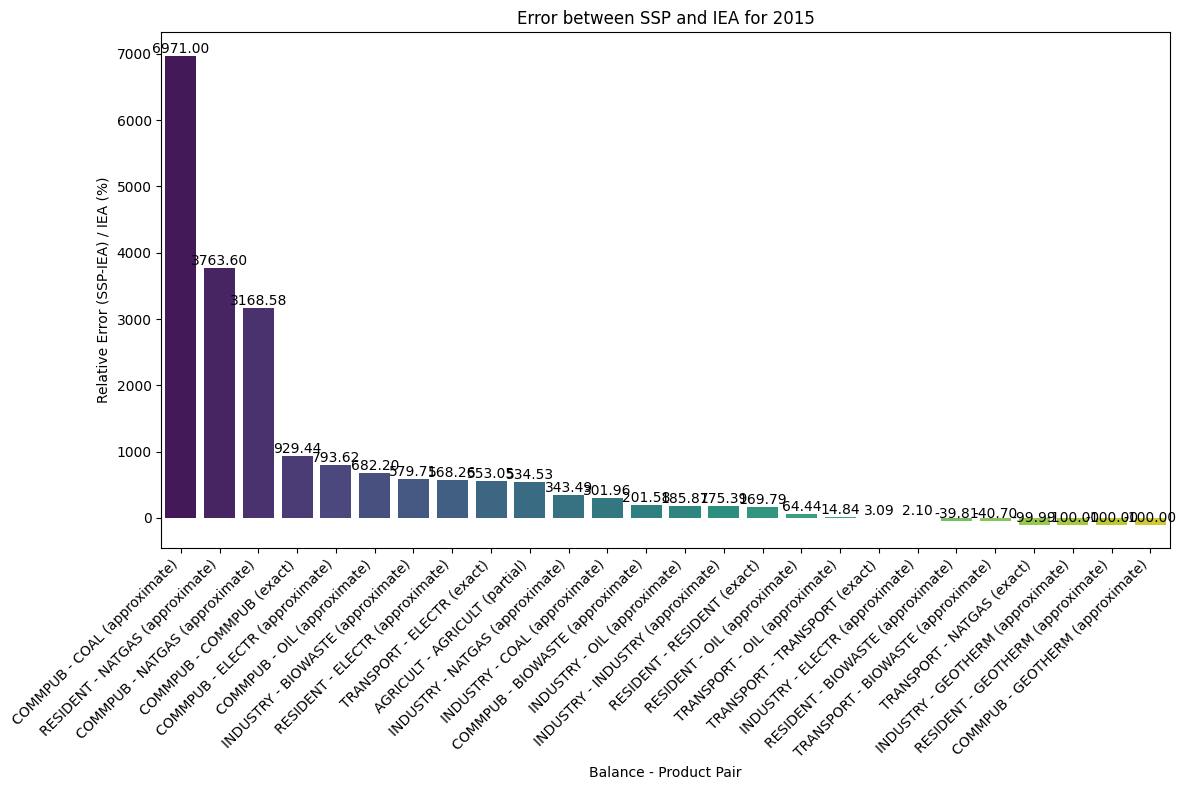

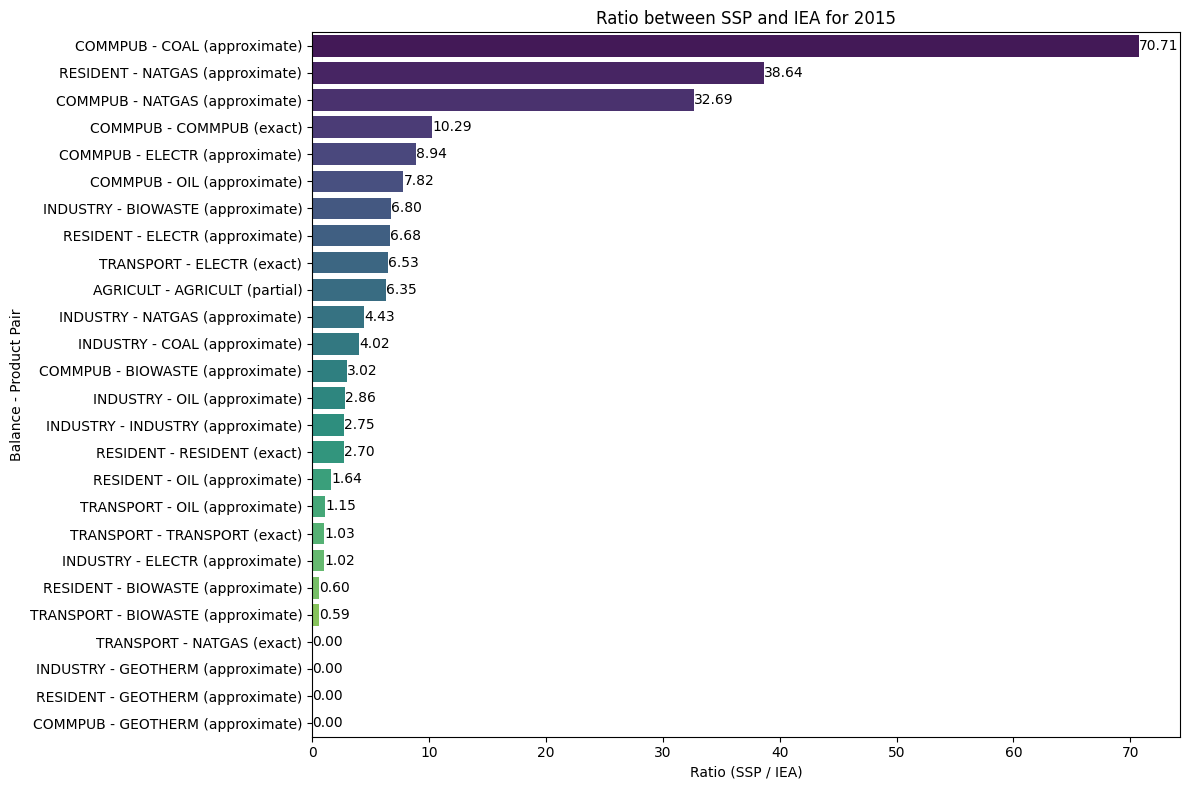

In [17]:
import importlib
import sisepuede.calibration._plotting
from sisepuede.calibration._plotting import plot_observation_comparisons, plot_metric_bar
importlib.reload(sisepuede.calibration._plotting)

# Example: Vertical bar plot of relative errors for YYYY
plot_metric_bar(
    df_comparison,
    year=2015,
    metric='error',
    orientation='vertical'
)

# Example: Horizontal bar plot of ratios for YYYY
plot_metric_bar(
    df_comparison,
    year=2015,
    metric='ratio',
    orientation='horizontal'
)

---
## 8.2 Visualise IEA and SSP values

Plot IEA (solid blue) vs SISEPUEDE (dashed red) for each matched (balance, product) pair.  A perfect calibration would have the two lines coincide over the historical period.

In [18]:
#Get the top N or bottom N pairs of (iea_balance_code, iea_product_code)

def get_top_bottom_pairs(
    df: pd.DataFrame,
    column_name: str,
    i: int,
    top: bool = True,
    agg: str = "mean",
    year: int | None = None,
    balance_col: str = "iea_balance_code",
    product_col: str = "iea_product_code",
) -> list[tuple]:
    
    df_filtered = df[df["year"] == year] if year is not None else df
    agged = (df_filtered.groupby([balance_col, product_col])[column_name].agg(agg))
    ranked = agged.reindex(agged.abs().sort_values(ascending=not top).index).head(i)
    
    return list(ranked.index)



# plot_pairs = []
# for row in pairs_with_both.itertuples(index=False):
#     plot_pairs.append((row.iea_balance_code, row.iea_product_code))

top_pairs = get_top_bottom_pairs(df_comparison, 'rel_err', 10, top = True, year = 2015)
bot_pairs = get_top_bottom_pairs(df_comparison, 'rel_err', 10, top = False, year = 2015)

Worst predicted targets


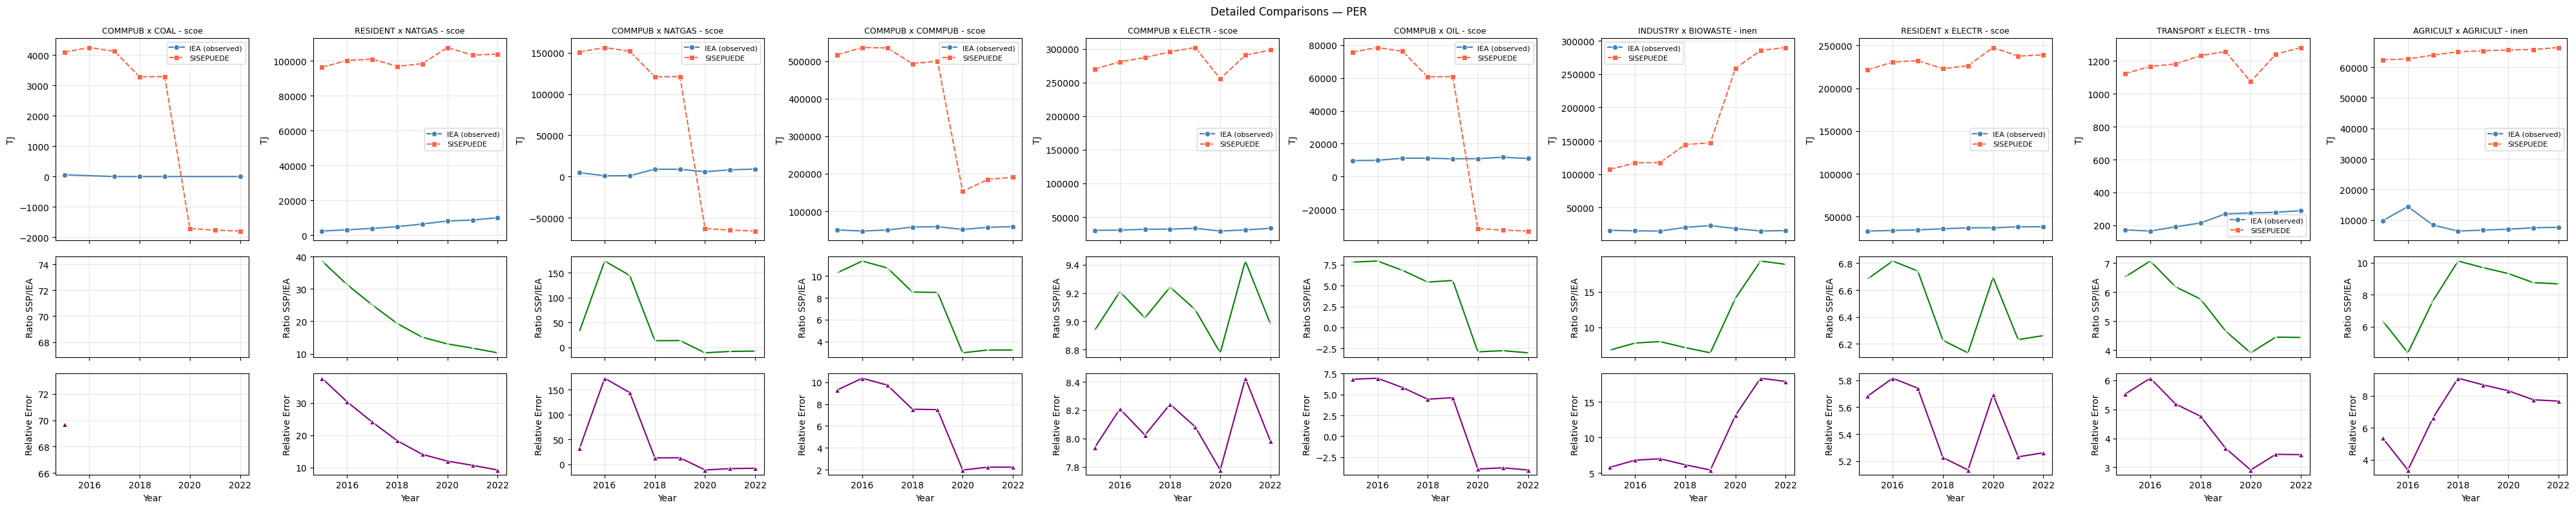

Best predicted targets


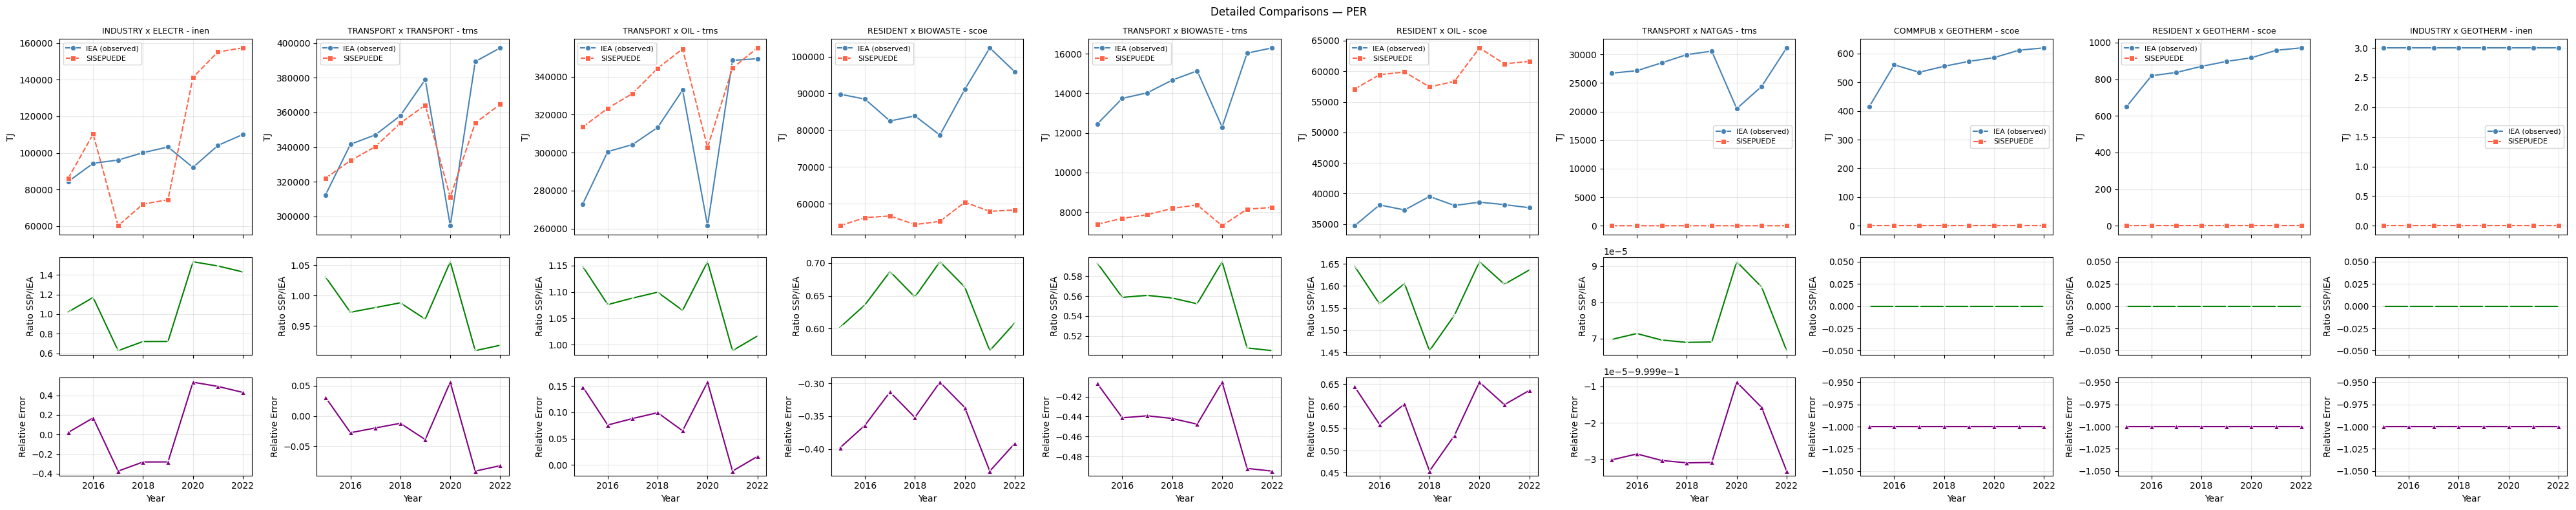

In [19]:
# # Detailed comparison for a single pair
# plot_observation_comparisons(
#     df_comparison,
#     pairs=('TRANSPORT', 'TRANSPORT'),
#     with_diagnostics=True,
#     second_var='ratio',
#     third_var='rel_err',
#     second_label='Ratio SSP/IEA',
#     third_label='Relative Error',
#     country=ISO_COUNTRY,
# )

print("Worst predicted targets")
# Detailed comparison for multiple pairs
plot_observation_comparisons(
    df_comparison,
    pairs=top_pairs,
    with_diagnostics=True,
    second_var='ratio',
    third_var='rel_err',
    second_label='Ratio SSP/IEA',
    third_label='Relative Error',
    country=ISO_COUNTRY,
)

print("Best predicted targets")
# Detailed comparison for multiple pairs
plot_observation_comparisons(
    df_comparison,
    pairs=bot_pairs,
    with_diagnostics=True,
    second_var='ratio',
    third_var='rel_err',
    second_label='Ratio SSP/IEA',
    third_label='Relative Error',
    country=ISO_COUNTRY,
)

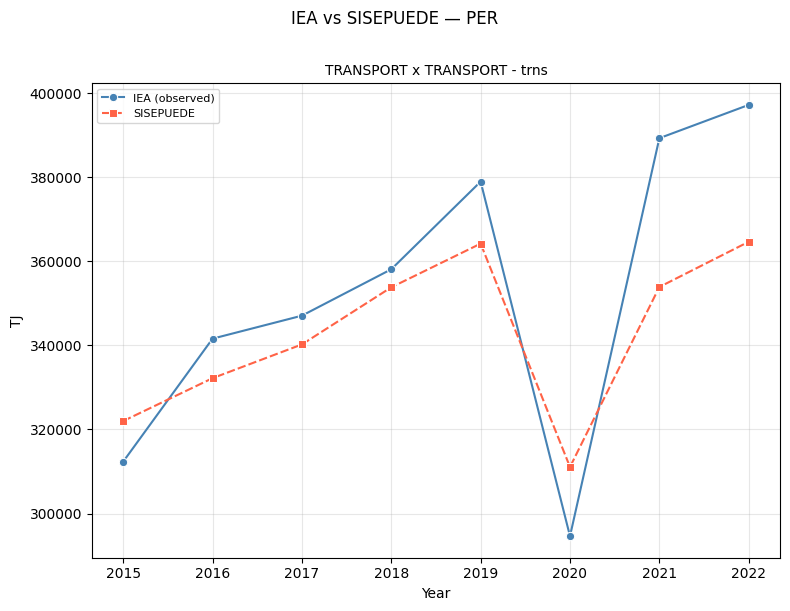

In [20]:
# Single plot: plot one pair
plot_observation_comparisons(
    df_comparison,
    [("TRANSPORT", "TRANSPORT")],
    country=ISO_COUNTRY,
)

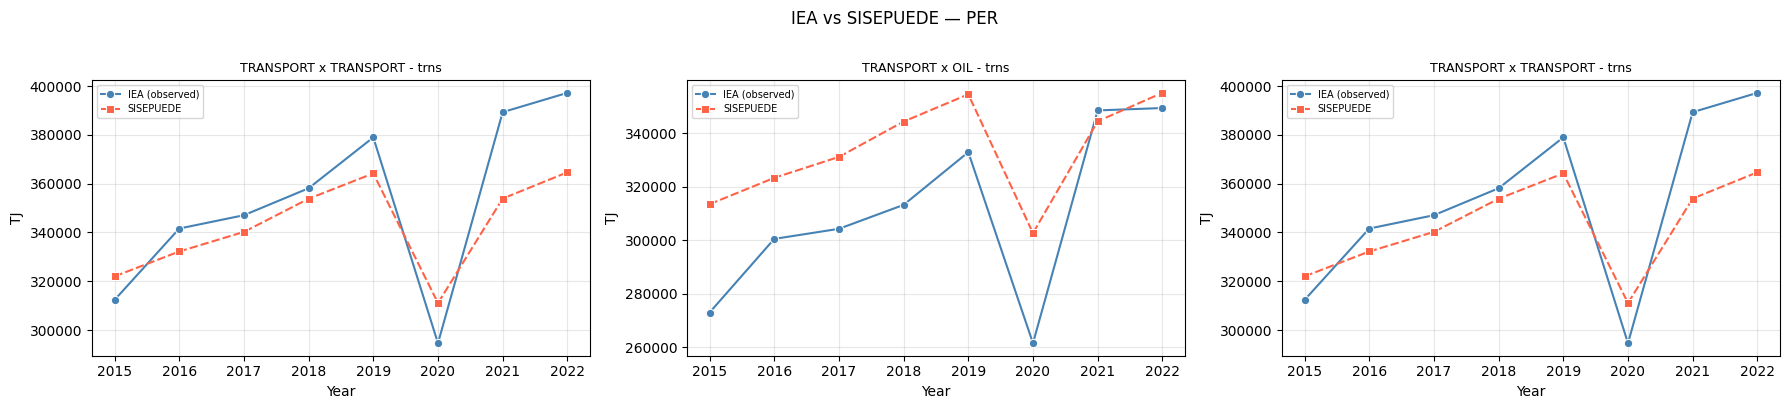

In [21]:
# Multiple panels: plot several pairs in separate panels
plot_observation_comparisons(
    df_comparison,
    [("TRANSPORT", "TRANSPORT"), ("TRANSPORT", "OIL"), ("TRANSPORT", "TRANSPORT")],
    # plot_pairs,
    country=ISO_COUNTRY,
)

#### NOTE TO SELF:
Relative error will break down when IEA is zero or near-zero. Dividing by a very small number produces enormous relative errors that aren't meaningful. This will happen for fuels that a country barely uses. 
We'll want to flag or exclude those cases rather than let them dominate the diagnostics, or apply a small threshold below which you ignore the relative error and fall back to absolute difference.


---
## 9. Export

In [22]:
PATH_OUTPUT = f"/Users/dianamendez/sisepuede-data/iea_vs_sisepuede_{ISO_COUNTRY}.csv"

df_comparison.to_csv(PATH_OUTPUT, index=False)
print(f"Saved to {PATH_OUTPUT}")

Saved to /Users/dianamendez/sisepuede-data/iea_vs_sisepuede_PER.csv
